In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import get_rollouts, shac
from flightning.envs import HoveringStateEnv
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import SHACActor, SHACCritic

%matplotlib inline


# Training a State-based Quadrotor Policy With SHAC

This notebook mirrors `train_bptt_state.ipynb` but replaces the BPTT
trainer with the Short-Horizon Actor Critic (SHAC) algorithm.
SHAC backpropagates actor gradients through a short-horizon rollout of
the (differentiable) flightning simulator while a separate critic is
trained by regression on TD-lambda returns and stabilised with an EMA
target critic.

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_shac = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]


## Define the Actor and Critic Networks

SHAC keeps the actor and critic separate. The actor outputs an action
mean; the critic outputs a scalar state value.

In [4]:
actor_net = SHACActor(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
critic_net = SHACCritic(
    [obs_dim, 512, 512, 1],
    initial_scale=0.01,
)

key_actor, key_critic = jax.random.split(key_init)
actor_params = actor_net.initialize(key_actor)
critic_params = critic_net.initialize(key_critic)


## Setup the Optimizers and Train States

In [5]:
N = 500
actor_tx = optax.adam(optax.cosine_decay_schedule(1e-3, N))
critic_tx = optax.adam(1e-3)

actor_state = TrainState.create(
    apply_fn=actor_net.apply, params=actor_params, tx=actor_tx
)
critic_state = TrainState.create(
    apply_fn=critic_net.apply, params=critic_params, tx=critic_tx
)

## Train the Policy Using SHAC

In [6]:
time_start = time.time()
res_dict = shac.train(
    env,
    actor_state,
    critic_state,
    num_epochs=N,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=64,
    key=key_shac,
    config=shac.Config(
        gamma=0.99,
        lam=0.95,
        critic_iterations=8,
        num_batches=4,
    ),
)
time_train = time.time() - time_start
print(f"Training time: {time_train:.1f}s")

[shac] epoch 0: actor_loss=0.117
[shac] epoch 10: actor_loss=0.171
[shac] epoch 20: actor_loss=0.186
[shac] epoch 30: actor_loss=0.199
[shac] epoch 40: actor_loss=0.166
[shac] epoch 50: actor_loss=0.150
[shac] epoch 60: actor_loss=0.116
[shac] epoch 70: actor_loss=0.094
[shac] epoch 80: actor_loss=0.092
[shac] epoch 90: actor_loss=0.083
[shac] epoch 100: actor_loss=0.086
[shac] epoch 110: actor_loss=0.074
[shac] epoch 120: actor_loss=0.077
[shac] epoch 130: actor_loss=0.071
[shac] epoch 140: actor_loss=0.063
[shac] epoch 150: actor_loss=0.062
[shac] epoch 160: actor_loss=0.061
[shac] epoch 170: actor_loss=0.061
[shac] epoch 180: actor_loss=0.058
[shac] epoch 190: actor_loss=0.061
[shac] epoch 200: actor_loss=0.055
[shac] epoch 210: actor_loss=0.055
[shac] epoch 220: actor_loss=0.054
[shac] epoch 230: actor_loss=0.051
[shac] epoch 240: actor_loss=0.053
[shac] epoch 250: actor_loss=0.052
[shac] epoch 260: actor_loss=0.051
[shac] epoch 270: actor_loss=0.051
[shac] epoch 280: actor_loss=0.

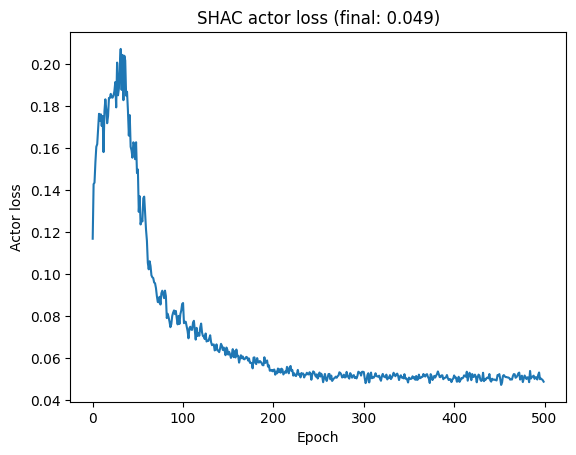

In [7]:
actor_losses = jnp.asarray(res_dict["metrics"]["actor_loss"])
plt.plot(actor_losses)
plt.title(f"SHAC actor loss (final: {actor_losses[-1]:.3f})")
plt.xlabel("Epoch")
plt.ylabel("Actor loss")
plt.show()

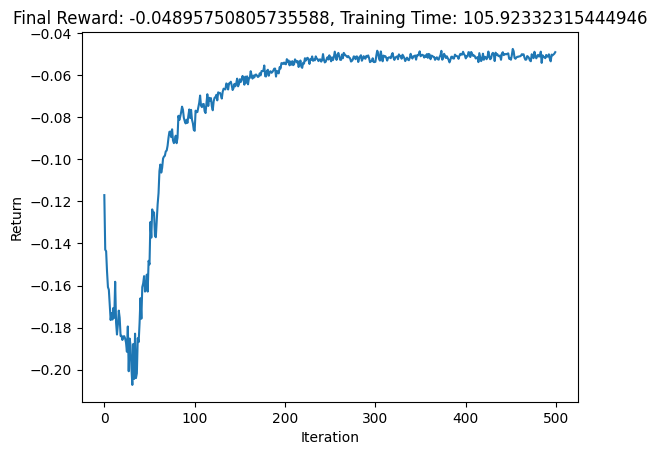

In [8]:
rewards = -jnp.asarray(res_dict["metrics"]["actor_loss"])
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [9]:
new_actor_state = res_dict["runner_state"].actor_state


def policy(obs, key):
    # deterministic rollout: use SHACActor.sample_action with deterministic=True
    sample = new_actor_state.apply_fn(
        new_actor_state.params, obs, key, True, method="sample_action"
    )
    return sample.action


/home/tong/tongworkspace/paperworkspace/rpg_flightning/flightning/envs/hovering_state_env.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


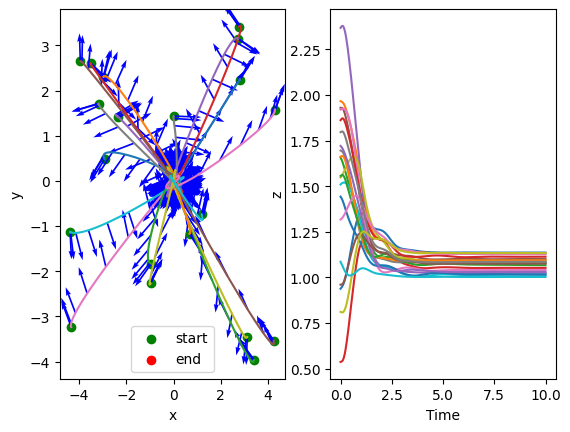

In [10]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=10 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)

transitions_eval = get_rollouts(env_eval, policy, 20, jax.random.key(3))
env_eval.plot_trajectories(transitions_eval)
